Name: Vinayak Sharma

Course: MCA(AI/ML)

Roll No: 2501940012

EXPERIMENT-2 (CNN)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 34ms/step - accuracy: 0.7961 - loss: 0.5569 - val_accuracy: 0.8584 - val_loss: 0.3860
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.8683 - loss: 0.3636 - val_accuracy: 0.8781 - val_loss: 0.3275
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 31ms/step - accuracy: 0.8843 - loss: 0.3145 - val_accuracy: 0.8914 - val_loss: 0.2887
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.8959 - loss: 0.2840 - val_accuracy: 0.9004 - val_loss: 0.2751
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9041 - loss: 0.2583 - val_accuracy: 0.9018 - val_loss: 0.2631
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.9126 - loss: 0.2381 - val_accuracy: 0.9070 - val_loss: 0.2532
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.9196 - loss: 0.2212 - val_accuracy: 0.9051 - val_loss: 0.2537
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.9239 - loss: 0.2033 - 

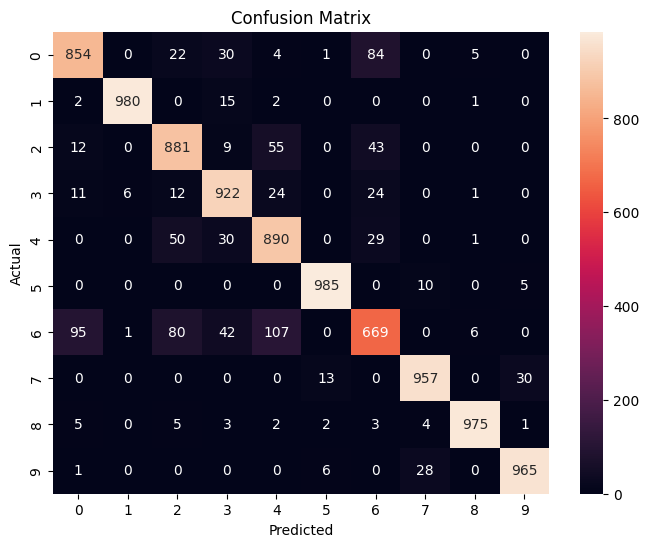

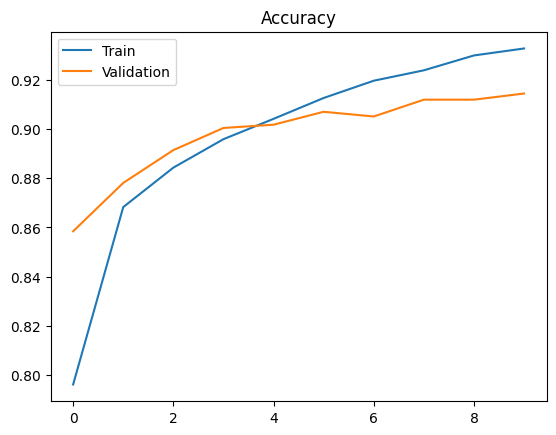

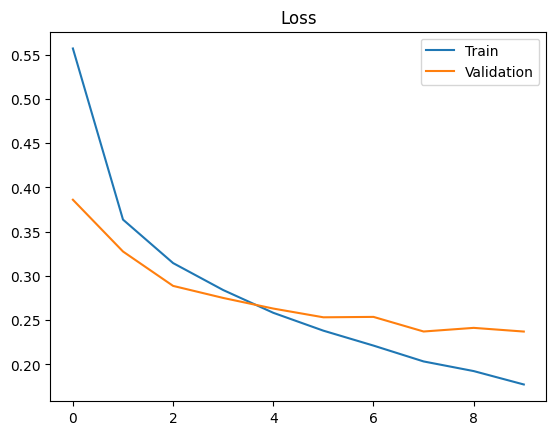

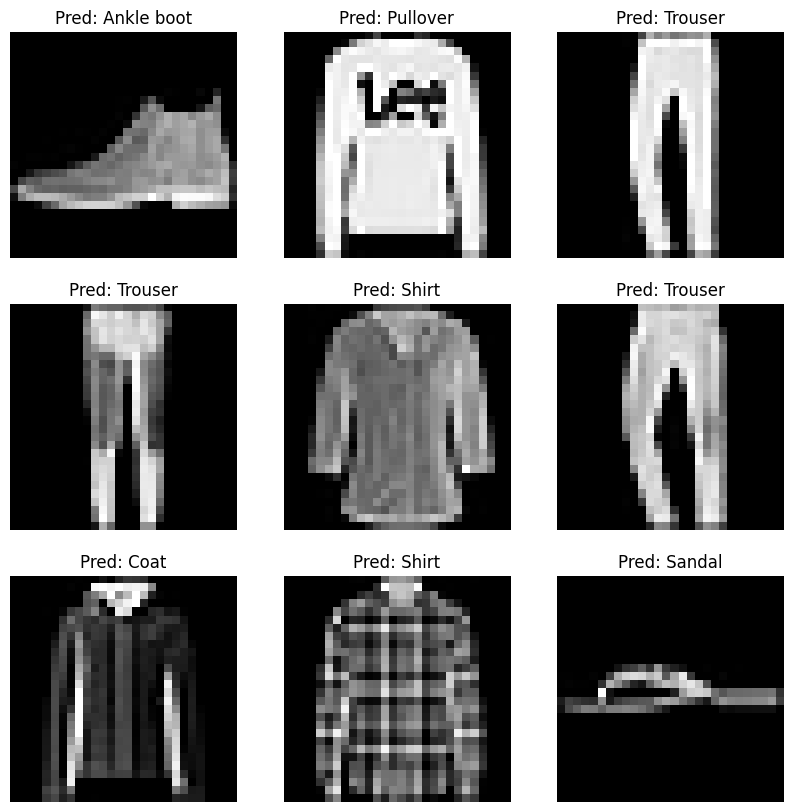

In [1]:
# 1. IMPORT LIBRARIES
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import classification_report, confusion_matrix

# 2. LOAD DATASET
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# 3. PREPROCESSING
# Normalize (0–255 → 0–1)
X_train = X_train / 255.0
X_test = X_test / 255.0

# Reshape (for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 4. BUILD CNN MODEL
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

# 5. COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. TRAIN MODEL
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# 7. EVALUATE MODEL
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

# 8. PREDICTIONS
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# 9. CLASSIFICATION REPORT
print(classification_report(y_test, y_pred_classes))

# 10. CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 11. PLOT TRAINING GRAPHS
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train', 'Validation'])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train', 'Validation'])
plt.show()

# 12. SHOW SAMPLE PREDICTIONS
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Pred: {class_names[y_pred_classes[i]]}")
    plt.axis('off')
plt.show()